# `sumo-marouter` — SUMO's macroscopic assignment as an external-simulator adapter

**What.** `sumo-marouter` wraps `eclipse-sumo`'s macroscopic stochastic
user-equilibrium tool `marouter` (Lopez et al. 2018, `[lopez2018microscopic]`,
[docs/REFERENCES.md](../../docs/REFERENCES.md)) as a benchmark model: it compiles a
fixed-demand, `power==1` (linear-latency) scenario into a real SUMO network, runs
`marouter` to convergence under ITS OWN hardcoded cost law, reads the per-edge
flows back into repo-native units, and lets the harness certify the equilibrium
gap under the scenario's DECLARED BPR costs (P1) — never marouter's own.

**Why it is in the benchmark.** It is the first EXTERNAL simulator on the
benchmark and the first row on the accuracy-vs-certificate ladder to ask a
production tool to solve the repo's own equilibrium: marouter's cost law is a
*hardcoded* linear-in-flow class function (PTV-Validate / VISUM-Cologne, not the
ITSC paper), so the adapter's job is a **compile map** — translating the
scenario's BPR coefficients into SUMO edge geometry (length, lane count) that
reproduces the SAME cost law to machine precision on every REPRESENTABLE link.
Three representability floors are unavoidable (a forced eps-intercept on
zero-intercept links, a parasitic slope on zero-slope links, integer lane
quantization) — refused loudly when they cannot be met, never silently clamped.
See the [model compendium](../../docs/MODELS.md) and
[docs/design/adr-027-sumo-marouter.md](../../docs/design/adr-027-sumo-marouter.md)
(P1, the compile-map derivation and every measured anchor).

**Scope.** A certified Braess run (the measured mapping floor, A1), the
MANDATORY cost-matched anchor separating that floor from solver error (A2 — "the
row is not shipped without A2"), the asymmetric two-route direction where a
converged white-box solver certifies an orders-of-magnitude better gap (A3, the
feasibility-is-not-equilibrium-quality headline), and the honest negative
control (`assignment_method="incremental"`, NOT an equilibrium) plus the traps
this adapter refuses rather than silently mis-scores.

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `Evaluator` from the flows
`marouter` emitted, in the cell where it is claimed; the adapter's own
`--tolerance` (SUE stability under ITS OWN costs) is never the certified gap.
`marouter` self-reports NO gap at all (`provides_gap=False`) — the certificate
is the only number, and it is the honest simulator-to-benchmark mapping floor,
never hidden ([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `sumo-marouter` is a GUARDED model behind the optional `eclipse-sumo`
# wheel (`pip install tabench[sumo]`) -- the ONLY guard cell in the tutorials so
# far. The inline backend is Agg-based (headless CI renders into the notebook);
# NEVER matplotlib.use("Agg") in-kernel -- it silently suppresses inline capture.
%matplotlib inline
try:
    import sumo  # noqa: F401  (the eclipse-sumo wheel; absence -> ModuleNotFoundError)
except ModuleNotFoundError as exc:
    if exc.name != "sumo":
        raise
    raise ModuleNotFoundError(
        "sumo-marouter needs the optional 'sumo' extra: pip install tabench[sumo]"
    ) from exc

import numpy as np

from tabench import (
    BiconjugateFrankWolfeModel,
    Budget,
    Evaluator,
    RngBundle,
    Trace,
    braess_scenario,
    two_route_scenario,
    viz,
)
from tabench.models.adapters import _sumo_io as sio
from tabench.models.adapters.sumo_marouter import SumoMarouterModel

## The compile-map story (adr-027, Decision 3)

`marouter` does not take a user BPR function: its congestion law is *hardcoded*
per SUMO road class, linear in flow, `t(f) = t0 (1 + K f/C)`. A repo link with
linear latency `t(v) = A + B v` (`power == 1` only) compiles to a SUMO edge
whose length/lane-count reproduce `(A, B)` via `t0 = A tau`, `slope = tau B/s`
at a flow scale `s` chosen so every REPRESENTABLE link's lane count is an exact
integer — matching the repo BPR to machine precision on those links. Zero-
intercept and zero-slope links force a small perturbation (an eps-intercept /
parasitic slope) that is the honest, MEASURED mapping floor below.

In [2]:
scenario = braess_scenario()  # demand=6.0, the A1 anchor
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"total demand  : {scenario.demand.total}")
print("task          : marouter macroscopic SUE under its own hardcoded linear vdf")

scenario      : braess
content hash  : cf00f411cdccec88…
total demand  : 6.0
task          : marouter macroscopic SUE under its own hardcoded linear vdf


## Solve

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)`. `sumo-marouter` maps `iterations ->
--max-iterations`; `marouter` exposes no shortest-path count, so `sp_calls`
is unmappable and an `sp_calls`-only budget is REFUSED rather than run
unbounded. `provides_gap=False`, and the model discloses (never hides) that
`marouter` does not report its executed iteration count
(`engine_iterations_executed_unknown=1`, provenance).

In [3]:
model = SumoMarouterModel()  # defaults: assignment_method="SUE", route_choice="logit"
bundle = model.solve(scenario, Budget(iterations=50), RngBundle(42), Trace())

final = bundle.final
print(f"model            : {model.name}")
print(f"emitted flows    : {np.round(final.link_flows, 6)}")
print(f"engine           : {bundle.seed_info.get('engine', 'unknown')}  (provenance)")
print(f"engine_iterations_executed_unknown : "
      f"{final.self_report['engine_iterations_executed_unknown']:.0f}  (disclosed, not hidden)")

model            : sumo-marouter
emitted flows    : [3.998156 2.001844 1.996313 2.001844 3.998156]
engine           : Eclipse SUMO marouter 1.27.1  (provenance)
engine_iterations_executed_unknown : 1  (disclosed, not hidden)


## Certify (P1) — A1, the measured Braess mapping floor

The harness scores `marouter`'s Braess flows against the SAME certificate every
white-box solver here earns. The certified gap is *real but small* — the
measured mapping floor, not solver error (A2, next cell, is what proves that).

In [4]:
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
print(f"certified relative gap  : {metrics['relative_gap']:.3e}")
print(f"feasible                : {metrics['feasible']:.0f}")
print(f"node_balance_residual   : {metrics['node_balance_residual']:.2e}")
assert metrics["feasible"] == 1.0
assert metrics["relative_gap"] < 3e-4  # loose, version-robust ceiling (measured ~1.74e-4)
assert metrics["node_balance_residual"] < 1e-6

# Analytic Braess UE anchor, recomputed in-cell: marouter's flows sit within the
# measured perturbation floor of the true oracle (4,2,2,2,4), not exactly on it.
ref_flows = np.array([4.0, 2.0, 2.0, 2.0, 4.0])
assert evaluator.evaluate(ref_flows)["relative_gap"] < 1e-6
assert np.allclose(final.link_flows, ref_flows, atol=0.01)
print(f"analytic UE flows       : {ref_flows}  (marouter within the mapping-floor perturbation)")

certified relative gap  : 1.739e-04
feasible                : 1
node_balance_residual   : 4.44e-16
analytic UE flows       : [4. 2. 2. 2. 4.]  (marouter within the mapping-floor perturbation)


## A2 — the MANDATORY cost-matched anchor

The certified gap above is only INTERPRETABLE if marouter's own internal costs
match the repo's declared BPR at the emitted flows on every representable link —
otherwise the "small gap" could just as well be a cost-model mismatch. This
notebook runs the SAME compile step + `marouter` invocation the adapter uses
internally (via the public `_sumo_io` converter), reads marouter's own
`traveltime` attribute, and diffs it against `scenario.network.link_cost` at the
emitted flows. "The row is not shipped without A2" (adr-027).

In [5]:
import os
import shutil
import subprocess
import tempfile


def _run_marouter_direct(scenario, theta, paths, method="SUE"):
    # The adapter's own compile+run steps, exposed here to read marouter's
    # INTERNAL traveltime attribute (not just the flows) -- the A2 cost-match check.
    workdir = tempfile.mkdtemp(prefix="tabench-sumo-a2-")
    try:
        build = sio.scenario_to_sumo(scenario, workdir, time_scale=1.0, min_lanes=1)
        netload = os.path.join(workdir, "nl.xml")
        cmd = [
            sio.sumo_binary("marouter"),
            "--net-file", build.net_file, "--additional-files", build.taz_file,
            "--od-matrix-files", build.od_file, "--netload-output", netload,
            "--output-file", os.devnull, "--precision", "9",
            "--weights.minor-penalty", "0", "--left-turn-penalty", "0",
            "--capacities.default", "true", "--assignment-method", method,
            "--route-choice-method", "logit", "--logit.beta", "0", "--logit.gamma", "0",
            "--logit.theta", repr(float(theta)), "--paths", str(paths),
            "--max-iterations", "50", "--max-inner-iterations", "5000",
            "--tolerance", "1e-7", "--seed", "42", "--routing-threads", "1",
        ]
        proc = subprocess.run(cmd, env=sio.sumo_env(), capture_output=True, text=True, cwd=workdir)
        assert proc.returncode == 0, proc.stderr[-1000:]
        n = scenario.network.n_links
        flows = sio.parse_netload(netload, n, build.flow_scale)
        tt = sio.parse_netload_attr(netload, n, "traveltime")
        return flows, tt, build
    finally:
        shutil.rmtree(workdir, ignore_errors=True)


for sc, label in ((braess_scenario(), "braess"), (two_route_scenario(sue_theta=None), "two-route")):
    # theta=200.0, paths=4: SumoMarouterModel()'s own defaults (logit_theta / time_scale
    # at time_scale=1.0, and the "paths" factor) -- this must be the SAME run the model
    # made above, or the cost-match check would not anchor A1/A3 at all.
    flows_a2, tt, build = _run_marouter_direct(sc, 200.0, 4)
    rep = build.representable
    repo_cost = sc.network.link_cost(flows_a2)
    diff = np.abs(tt[rep] / build.time_scale - repo_cost[rep])
    print(f"{label:10s}: {rep.sum()}/{len(rep)} representable links, "
          f"max |marouter cost - repo BPR cost| = {diff.max():.2e}")
    assert rep.any()
    assert diff.max() < 1e-6

braess    : 3/5 representable links, max |marouter cost - repo BPR cost| = 3.57e-10


two-route : 2/4 representable links, max |marouter cost - repo BPR cost| = 1.56e-10


## A3 — asymmetric two-route: feasibility is not equilibrium quality

On the ASYMMETRIC two-route corridor (deterministic UE `f_A = 2.5` at `D=4`;
`theta` is calibrated on THIS anchor, never symmetric Braess, whose UE is the
equal split at any `theta`), `marouter` certifies a small but real gap while a
converged white-box `bfw` certifies an orders-of-magnitude better one — the
honest headline of this whole external-engine ladder: an industrially converged
simulator run is not the same claim as a certified equilibrium.

In [6]:
sc_tr = two_route_scenario(sue_theta=None)
bundle_tr = SumoMarouterModel().solve(sc_tr, Budget(iterations=50), RngBundle(42), Trace())
metrics_tr = Evaluator(sc_tr).evaluate(bundle_tr.final.link_flows)
print(f"marouter  : relative_gap = {metrics_tr['relative_gap']:.3e}")
assert metrics_tr["feasible"] == 1.0
assert metrics_tr["relative_gap"] < 1e-3

bfw_trace = Trace()
BiconjugateFrankWolfeModel().solve(
    sc_tr, Budget(iterations=200, target_relative_gap=1e-10), RngBundle(0), bfw_trace
)
bfw_gap = Evaluator(sc_tr).evaluate(bfw_trace.final.link_flows)["relative_gap"]
print(f"bfw       : relative_gap = {bfw_gap:.3e}  (an orders-of-magnitude better certificate)")
assert bfw_gap < metrics_tr["relative_gap"] / 10.0

marouter  : relative_gap = 5.445e-04
bfw       : relative_gap = 0.000e+00  (an orders-of-magnitude better certificate)


## The honest negative control, and the traps this adapter refuses

`marouter`'s DEFAULT `assignment_method="incremental"` is NOT an equilibrium —
certified here as a much worse gap, feasible but honestly far from UE. Three
more traps are refused loudly rather than silently mis-scored:
`assignment_method="UE"` (marouter silently falls back to SUE — declaring it
would poison the manifest), non-logit route choice (`gawron`/`lohse` emit
all-zero flows in this macroscopic setting), and an SUE-scenario (marouter's
adapter targets the deterministic instance only).

In [7]:
bundle_inc = SumoMarouterModel(assignment_method="incremental").solve(
    scenario, Budget(iterations=50), RngBundle(42), Trace()
)
metrics_inc = Evaluator(scenario).evaluate(bundle_inc.final.link_flows)
print(f"incremental (default, NOT an equilibrium) : "
      f"relative_gap = {metrics_inc['relative_gap']:.3e}  feasible = {metrics_inc['feasible']:.0f}")
assert metrics_inc["feasible"] == 1.0
assert metrics_inc["relative_gap"] > 0.05  # honestly much worse than SUE's mapping floor

try:
    SumoMarouterModel(assignment_method="UE").solve(scenario, Budget(iterations=5), RngBundle(0), Trace())
    raise AssertionError("expected assignment_method='UE' to be refused")
except ValueError as exc:
    print(f"assignment_method='UE' refused : {exc}"[:100] + "…")

try:
    SumoMarouterModel(route_choice="gawron").solve(scenario, Budget(iterations=5), RngBundle(0), Trace())
    raise AssertionError("expected route_choice='gawron' to be refused")
except ValueError as exc:
    print(f"route_choice='gawron' refused  : {exc}"[:100] + "…")

try:
    SumoMarouterModel().solve(two_route_scenario(), Budget(iterations=5), RngBundle(0), Trace())
    raise AssertionError("expected an SUE-theta scenario to be refused")
except ValueError as exc:
    print(f"SUE-theta scenario refused     : {exc}"[:100] + "…")

incremental (default, NOT an equilibrium) : relative_gap = 7.128e-02  feasible = 1
assignment_method='UE' refused : assignment_method='UE' is refused: marouter does not implement dete…
route_choice='gawron' refused  : route_choice is restricted to 'logit' (gawron/lohse emit all-zero f…
SUE-theta scenario refused     : sumo-marouter accepts only fixed-demand power==1 UE scenarios; scen…


## Visualize

`sumo-marouter`'s certified artifact is per-LINK flows on a road `Network` —
the same artifact shape every static/day-to-day model here emits — so
`tabench.viz` applies directly (adr-035's viz rule).

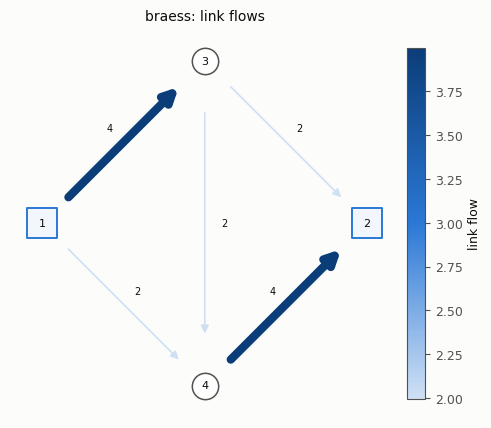

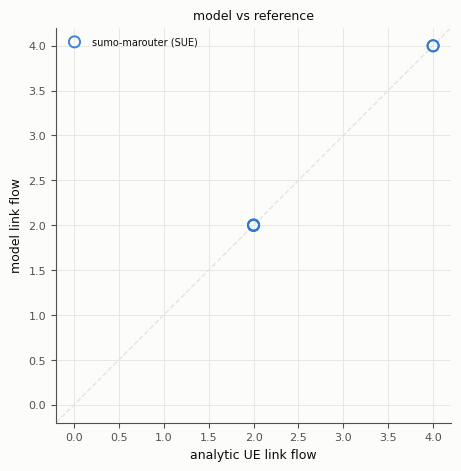

In [8]:
display(viz.plot_network_flows(scenario.network, final.link_flows))
display(viz.plot_flow_scatter(("analytic UE", ref_flows), {"sumo-marouter (SUE)": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** `marouter` reports no gap at all
  (`provides_gap=False`); every number above came from the harness's own
  `Evaluator`, recomputed from the emitted flows.
- **A2 is the load-bearing anchor.** Without proving marouter's own costs match
  the declared BPR on representable links, "the gap is small" would not mean
  "the mapping is faithful" — it could just as well be a cost-model mismatch.
- **Feasible is not equilibrium.** A3 makes the headline literal: `marouter`'s
  industrially converged SUE and `bfw`'s certified equilibrium are DIFFERENT
  claims, scored on the same axis, and `bfw` wins the convergence axis as
  expected.
- **Where next.** the compile-map derivation and every representability floor
  in [docs/design/adr-027-sumo-marouter.md](../../docs/design/adr-027-sumo-marouter.md);
  the white-box UE ladder this compares against
  [`bfw`](../01-static/05-bfw.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md).